In [ ]:
import pandas as pd

# Data Preprocessing

## icustays 불러오기, 입원기간 컬럼 만들기 (입원기간은 당일 퇴원도 1일로 치며 과거 입원까지 합쳐 환자의 총 입원 기간을 계산함.)

In [ ]:
df_icu = pd.read_csv('team_data/icustays.csv')
df_icu.columns = ['환자id', '입원환자 id', '입원 기간 id', '첫번째 병동', '마지막 병동', '입실기간', '퇴실기간', '입원기간']
df_icu['입원기간'] = df_icu['입원기간'].astype('int')+1
total_stay = df_icu.groupby('환자id')['입원기간'].sum()
df_icu = df_icu.drop_duplicates('환자id')
df_icu = df_icu.set_index('환자id')
df_icu['총 입원 기간'] = total_stay
df_icu.drop(columns = '입원기간', inplace=True)
df_icu = df_icu.reset_index()
df_icu

,환자id,입원환자 id,입원 기간 id,첫번째 병동,마지막 병동,입실기간,퇴실기간,총 입원 기간
0,10000032,29079034,39553978,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2180-07-23 14:00:00,2180-07-23 23:50:47,1
1,10000980,26913865,39765666,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2189-06-27 08:42:00,2189-06-27 20:38:27,1
2,10001217,24597018,37067082,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2157-11-20 19:18:02,2157-11-21 22:08:00,3
3,10001725,25563031,31205490,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2110-04-11 15:52:22,2110-04-12 23:59:56,2
4,10001884,26184834,37510196,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2131-01-11 04:20:05,2131-01-20 08:27:30,10
...,...,...,...,...,...,...,...,...
50915,19999442,26785317,32336619,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2148-11-19 14:23:43,2148-11-26 13:12:15,7
50916,19999625,25304202,31070865,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2139-10-10 19:18:00,2139-10-11 18:21:28,1
50917,19999828,25744818,36075953,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2149-01-08 18:12:00,2149-01-10 13:11:02,2
50918,19999840,21033226,38978960,Trauma SICU (TSICU),Surgical Intensive Care Unit (SICU),2164-09-12 09:26:28,2164-09-17 16:35:15,6


## patients 테이블 로드

In [ ]:
df_patients = pd.read_csv('team_data/patients.csv')
df_patients.columns = ['환자id', '성별', '나이', '특정 사건이 일어난 년도', '연도 그룹', '사망 날짜']
df_patients

,환자id,성별,나이,특정 사건이 일어난 년도,연도 그룹,사망 날짜
0,10000032,F,52,2180,2014 - 2016,2180-09-09
1,10000048,F,23,2126,2008 - 2010,NaN
2,10000068,F,19,2160,2008 - 2010,NaN
3,10000084,M,72,2160,2017 - 2019,2161-02-13
4,10000102,F,27,2136,2008 - 2010,NaN
...,...,...,...,...,...,...
299707,19999828,F,46,2147,2017 - 2019,NaN
299708,19999829,F,28,2186,2008 - 2010,NaN
299709,19999840,M,58,2164,2008 - 2010,2164-09-17
299710,19999914,F,49,2158,2017 - 2019,NaN


## admissions 테이블 로드

In [ ]:
df_admissions = pd.read_csv('team_data/admissions.csv')
df_admissions.columns = ['환자id', '병원 직원 id', '입원 시간', '퇴원 시간', '환자 사망 시간', '입원 유형', '담당 의사 id', '입원 경로', '인계 경로', '보험 종류', '언어', '결혼 상태', '인종', '응급실 입원 시간', '응급실 퇴원 시간', '사망여부']
df_admissions

,환자id,병원 직원 id,입원 시간,퇴원 시간,환자 사망 시간,입원 유형,담당 의사 id,입원 경로,인계 경로,보험 종류,언어,결혼 상태,인종,응급실 입원 시간,응급실 퇴원 시간,사망여부
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P874LG,TRANSFER FROM HOSPITAL,HOME,Other,ENGLISH,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0
1,10000032,22841357,2180-06-26 18:27:00,2180-06-27 18:49:00,NaN,EW EMER.,P09Q6Y,EMERGENCY ROOM,HOME,Medicaid,ENGLISH,WIDOWED,WHITE,2180-06-26 15:54:00,2180-06-26 21:31:00,0
2,10000032,25742920,2180-08-05 23:44:00,2180-08-07 17:50:00,NaN,EW EMER.,P60CC5,EMERGENCY ROOM,HOSPICE,Medicaid,ENGLISH,WIDOWED,WHITE,2180-08-05 20:58:00,2180-08-06 01:44:00,0
3,10000032,29079034,2180-07-23 12:35:00,2180-07-25 17:55:00,NaN,EW EMER.,P30KEH,EMERGENCY ROOM,HOME,Medicaid,ENGLISH,WIDOWED,WHITE,2180-07-23 05:54:00,2180-07-23 14:00:00,0
4,10000068,25022803,2160-03-03 23:16:00,2160-03-04 06:26:00,NaN,EU OBSERVATION,P51VDL,EMERGENCY ROOM,NaN,Other,ENGLISH,SINGLE,WHITE,2160-03-03 21:55:00,2160-03-04 06:26:00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
431226,19999828,25744818,2149-01-08 16:44:00,2149-01-18 17:00:00,NaN,EW EMER.,P75BG6,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,Other,ENGLISH,SINGLE,WHITE,2149-01-08 09:11:00,2149-01-08 18:12:00,0
431227,19999828,29734428,2147-07-18 16:23:00,2147-08-04 18:10:00,NaN,EW EMER.,P16C7J,PHYSICIAN REFERRAL,HOME HEALTH CARE,Other,ENGLISH,SINGLE,WHITE,2147-07-17 17:18:00,2147-07-18 17:34:00,0
431228,19999840,21033226,2164-09-10 13:47:00,2164-09-17 13:42:00,2164-09-17 13:42:00,EW EMER.,P58A9J,EMERGENCY ROOM,DIED,Other,ENGLISH,WIDOWED,WHITE,2164-09-10 11:09:00,2164-09-10 14:46:00,1
431229,19999840,26071774,2164-07-25 00:27:00,2164-07-28 12:15:00,NaN,EW EMER.,P506DE,EMERGENCY ROOM,HOME,Other,ENGLISH,WIDOWED,WHITE,2164-07-24 21:16:00,2164-07-25 01:20:00,0


## diagnoses_icd 테이블 로드

In [ ]:
df_diag = pd.read_csv('team_data/diagnoses_icd.csv')
df_diag.columns = ['환자id', '병원직원id', '진단 코드의 순서', 'icd 진단 코드', '해당 진단 코드의 ICD 버전']
df_diag.drop('해당 진단 코드의 ICD 버전', errors = 'ignore', inplace = True)
last_icd = df_diag.loc[df_diag.groupby('환자id')['진단 코드의 순서'].idxmax()]
last_icd

,환자id,병원직원id,진단 코드의 순서,icd 진단 코드,해당 진단 코드의 ICD 버전
38,10000032,29079034,13,5715,9
39,10000068,25022803,1,30500,9
45,10000084,23052089,6,Z8546,10
53,10000108,27250926,2,52109,9
75,10000117,27988844,13,Z7901,10
...,...,...,...,...,...
4756100,19999733,27674281,3,E8490,9
4756130,19999784,23406899,12,I10,10
4756295,19999828,29734428,22,I9581,10
4756307,19999840,21033226,12,E912,9


## procedureevents 테이블 로드

In [ ]:
df_procedure = pd.read_csv('team_data/procedureevents.csv')
df_procedure

,subject_id,hadm_id,stay_id,caregiver_id,starttime,endtime,storetime,itemid,value,valueuom,...,orderid,linkorderid,ordercategoryname,ordercategorydescription,patientweight,isopenbag,continueinnextdept,statusdescription,originalamount,originalrate
0,10000032,29079034,39553978,88981.0,2180-07-23 14:43:00,2180-07-23 14:44:00,2180-07-23 14:43:00,225966,1.0,NaN,...,6416557,6416557,Procedures,Task,39.4,0,0,FinishedRunning,1.0,0
1,10000032,29079034,39553978,NaN,2180-07-23 14:24:00,2180-07-23 23:50:00,2180-07-23 23:50:49.983,224275,566.0,min,...,6497934,6497934,Peripheral Lines,ContinuousProcess,39.4,1,0,FinishedRunning,566.0,1
2,10000032,29079034,39553978,NaN,2180-07-23 14:24:00,2180-07-23 23:50:00,2180-07-23 23:50:49.983,224277,566.0,min,...,9643097,9643097,Peripheral Lines,ContinuousProcess,39.4,1,0,FinishedRunning,566.0,1
3,10000980,26913865,39765666,NaN,2189-06-27 09:01:00,2189-06-27 20:38:00,2189-06-27 20:38:29.047,225794,697.0,min,...,5989583,5989583,Ventilation,ContinuousProcess,76.2,1,0,FinishedRunning,697.0,1
4,10000980,26913865,39765666,NaN,2189-06-27 09:15:00,2189-06-27 20:38:00,2189-06-27 20:38:29.047,224277,683.0,min,...,476764,476764,Peripheral Lines,ContinuousProcess,76.2,1,0,FinishedRunning,683.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
696087,19999987,23865745,36195440,90295.0,2145-11-02 23:28:00,2145-11-02 23:29:00,2145-11-02 23:28:00,225966,1.0,NaN,...,6438362,6438362,Procedures,Task,60.0,0,0,FinishedRunning,1.0,0
696088,19999987,23865745,36195440,90295.0,2145-11-02 23:34:00,2145-11-04 04:45:00,2145-11-04 05:24:00,224277,1751.0,min,...,3357951,3357951,Peripheral Lines,ContinuousProcess,60.0,1,0,FinishedRunning,1751.0,1
696089,19999987,23865745,36195440,90295.0,2145-11-02 23:34:00,2145-11-04 07:49:00,2145-11-04 08:20:00,224275,1935.0,min,...,8504627,8504627,Peripheral Lines,ContinuousProcess,60.0,1,0,FinishedRunning,1935.0,1
696090,19999987,23865745,36195440,90295.0,2145-11-02 23:34:00,2145-11-04 19:15:00,2145-11-04 20:39:00,224277,2621.0,min,...,617277,617277,Peripheral Lines,ContinuousProcess,60.0,1,0,FinishedRunning,2621.0,1


## drgcodes 테이블 로드

In [ ]:
df_drgcode = pd.read_csv('team_data/drgcodes.csv')
df_drgcode

,subject_id,hadm_id,drg_type,drg_code,description,drg_severity,drg_mortality
0,10000032,22595853,APR,283,OTHER DISORDERS OF THE LIVER,2.0,2.0
1,10000032,22595853,HCFA,442,"DISORDERS OF LIVER EXCEPT MALIG,CIRR,ALC HEPA ...",NaN,NaN
2,10000032,22841357,APR,279,HEPATIC COMA & OTHER MAJOR ACUTE LIVER DISORDERS,3.0,2.0
3,10000032,22841357,HCFA,442,"DISORDERS OF LIVER EXCEPT MALIG,CIRR,ALC HEPA ...",NaN,NaN
4,10000032,25742920,APR,283,OTHER DISORDERS OF THE LIVER,3.0,2.0
...,...,...,...,...,...,...,...
604372,19999840,21033226,HCFA,100,SEIZURES W MCC,NaN,NaN
604373,19999840,26071774,APR,45,CVA & PRECEREBRAL OCCLUSION W INFARCT,2.0,1.0
604374,19999840,26071774,HCFA,65,INTRACRANIAL HEMORRHAGE OR CEREBRAL INFARCTION...,NaN,NaN
604375,19999987,23865745,APR,44,INTRACRANIAL HEMORRHAGE,4.0,4.0


## 본격적인 데이터 전처리.
* 1) admission -> icu -> patients 테이블 순서로 조인 및 사용할 컬럼만 select
* 2) icustays 테이블과 조인
* 3) procedureevenets 테이블과 조인
* 4) drgcodes 테이블과 조인
* 5) 결측치 조인
* GPT의 힘을 빌리지 않고 하려다보니, 코드가 좀 지저분해졌습니다. 양해 부탁드립니다.

In [ ]:
def f1(x):
    x = x.fillna(0)
    return x.max()

# 1번 과정
df = pd.DataFrame()
result_ad = df_admissions[df_admissions['환자id'].isin(df_icu['환자id'])] #admissions와 icu 테이블 조인
result_ad_2 = result_ad[result_ad['환자id'].isin(df_patients['환자id'])] #조인한 테이블과 patients 테이블 조인
result_ad_2['환자id'] = result_ad_2['환자id'].sort_values()
df = pd.concat([df, result_ad_2[['환자id', '인종', '결혼 상태', '사망여부']]], axis=1)
df = df.drop_duplicates('환자id')
df = df.set_index('환자id')
idx = list(df.index)
df = pd.concat([df, df_patients.set_index('환자id').loc[idx][['성별', '나이']]], axis=1) #patients에서 조인한 테이블과 같은 환자id의 성별, 나이 추출
df = df.reset_index()
df = df.set_index('환자id')
result = df[['성별', '나이', '인종', '결혼 상태', '사망여부']]

# 2번 과정: 입원 기간을 추가하기 위해 icustays와 조인
result = result.reset_index()
df_icu2 = df_icu[df_icu['환자id'].isin(result['환자id'])]
df_stay = df_icu2.sort_values('환자id')[['환자id', '총 입원 기간']]
df_stay = df_stay.set_index('환자id')
result = result.set_index('환자id')
result = pd.concat([result, df_stay], axis=1)

#현재 result에는 성별, 나이, 인종, 결혼상태, 사망여부, 총 입원 기간이 존재.

# 3번 과정: 환자 체중 추가하기 위해 procedure과 조인
sr1 = df_procedure.groupby("subject_id")['patientweight'].apply(lambda x: x.iloc[-1]) #환자의 마지막 체중을 최종 체중으로 사용.
sr1 = sr1.sort_index()
df_weight = sr1.reset_index()
df_weight = df_weight[df_weight['subject_id'].isin(result.index)] #조인
df_weight = df_weight.set_index('subject_id')
idx = df_weight.index
result = result.loc[idx]
result['체중'] = df_weight['patientweight']

# 4번 과정: 사망 위험도 추가하기 위해 drgcodes와 조인
sr2 = df_drgcode.groupby('subject_id')['drg_mortality'].apply(f1) #결측치 제거
sr2 = sr2.sort_index()
df_mortality = sr2.reset_index()
df_mortality = df_mortality[df_mortality['subject_id'].isin(result.index)] #조인
df_mortality = df_mortality.set_index('subject_id')
idx = df_mortality.index
result = result.loc[idx]
result['사망 위험도'] = df_mortality['drg_mortality']
result.index.name = '환자id'

#결측치 처리. unknown은 결혼 여부를 알 수 없음을 의미.
result['결혼 상태'] = result['결혼 상태'].fillna('UNKNOWN')
result

,성별,나이,인종,결혼 상태,사망여부,총 입원 기간,체중,사망 위험도
환자id,,,,,,,,
10000032,F,52,WHITE,WIDOWED,0,1,39.4,3.0
10000980,F,73,BLACK/AFRICAN AMERICAN,MARRIED,0,1,76.2,4.0
10001217,F,55,WHITE,MARRIED,0,3,74.8,4.0
10001725,F,46,WHITE,MARRIED,0,2,72.2,1.0
10001884,F,68,BLACK/AFRICAN AMERICAN,MARRIED,0,10,65.0,3.0
...,...,...,...,...,...,...,...,...
19999442,M,41,WHITE,SINGLE,0,7,107.5,4.0
19999625,M,81,WHITE,MARRIED,0,1,50.5,4.0
19999828,F,46,WHITE,SINGLE,0,2,67.9,2.0


## 조인한 테이블 결측치 확인

In [ ]:
result.isnull().sum()

성별         0
나이         0
인종         0
결혼 상태      0
사망여부       0
총 입원 기간    0
체중         0
사망 위험도     0
dtype: int64

## diagnoses_icd 코드와 조인
* 위 전처리 코드가 너무 길어져 가독성을 위해 나누었습니다.

In [ ]:
result_sub = result.reset_index()
df_sub = result_sub[result_sub['환자id'].isin(last_icd['환자id'])]
df_sub = df_sub.set_index('환자id')
df_sub

,성별,나이,인종,결혼 상태,사망여부,총 입원 기간,체중,사망 위험도
환자id,,,,,,,,
10000032,F,52,WHITE,WIDOWED,0,1,39.4,3.0
10000980,F,73,BLACK/AFRICAN AMERICAN,MARRIED,0,1,76.2,4.0
10001217,F,55,WHITE,MARRIED,0,3,74.8,4.0
10001725,F,46,WHITE,MARRIED,0,2,72.2,1.0
10001884,F,68,BLACK/AFRICAN AMERICAN,MARRIED,0,10,65.0,3.0
...,...,...,...,...,...,...,...,...
19999442,M,41,WHITE,SINGLE,0,7,107.5,4.0
19999625,M,81,WHITE,MARRIED,0,1,50.5,4.0
19999828,F,46,WHITE,SINGLE,0,2,67.9,2.0


In [ ]:
last_icd_copy =last_icd.copy()
last_icd_copy = last_icd_copy.set_index('환자id')
last_icd_copy

,병원직원id,진단 코드의 순서,icd 진단 코드,해당 진단 코드의 ICD 버전
환자id,,,,
10000032,29079034,13,5715,9
10000068,25022803,1,30500,9
10000084,23052089,6,Z8546,10
10000108,27250926,2,52109,9
10000117,27988844,13,Z7901,10
...,...,...,...,...
19999733,27674281,3,E8490,9
19999784,23406899,12,I10,10
19999828,29734428,22,I9581,10


## 최종 DataFrame 추출.
* 체중이 25 이하, 200 이상인 사람들은 측정 오류일 가능성이 커 제외했습니다.

In [ ]:
# 최종 DataFrame 추출
idx = df_sub.index
temp = last_icd_copy.loc[idx][['icd 진단 코드', '해당 진단 코드의 ICD 버전']]
final_df = pd.concat([df_sub, temp], axis=1)
final_df = final_df[['성별', '나이', '인종', '결혼 상태', 'icd 진단 코드', '해당 진단 코드의 ICD 버전', '체중', '총 입원 기간', '사망 위험도', '사망여부']]
final_df = final_df[(final_df['체중']>=25) & (final_df['체중']<=200)]
final_df

,성별,나이,인종,결혼 상태,icd 진단 코드,해당 진단 코드의 ICD 버전,체중,총 입원 기간,사망 위험도,사망여부
환자id,,,,,,,,,,
10000032,F,52,WHITE,WIDOWED,5715,9,39.4,1,3.0,0
10000980,F,73,BLACK/AFRICAN AMERICAN,MARRIED,E8497,9,76.2,1,4.0,0
10001217,F,55,WHITE,MARRIED,V161,9,74.8,3,4.0,0
10001725,F,46,WHITE,MARRIED,78052,9,72.2,2,1.0,0
10001884,F,68,BLACK/AFRICAN AMERICAN,MARRIED,T45515A,10,65.0,10,3.0,0
...,...,...,...,...,...,...,...,...,...,...
19999442,M,41,WHITE,SINGLE,311,9,107.5,7,4.0,0
19999625,M,81,WHITE,MARRIED,V4589,9,50.5,1,4.0,0
19999828,F,46,WHITE,SINGLE,I9581,10,67.9,2,2.0,0


## 최종 데이터 프레임 결측치 확인

In [ ]:
final_df.isnull().sum()

성별                  0
나이                  0
인종                  0
결혼 상태               0
icd 진단 코드           0
해당 진단 코드의 ICD 버전    0
체중                  0
총 입원 기간             0
사망 위험도              0
사망여부                0
dtype: int64

## CSV 파일로 저장

In [ ]:
final_df.to_csv('C:/Users/USER/OneDrive - 수원대학교/바탕 화면/데이터베이스/final_df.csv', index=True, encoding='utf-8-sig')

# 파이썬으로 SQL에 데이터 Bulk

## 데이터 한 번 더 확인

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('final_df.csv', index_col = 0)
df

,성별,나이,인종,결혼 상태,icd 진단 코드,해당 진단 코드의 ICD 버전,체중,총 입원 기간,사망 위험도,사망여부
환자id,,,,,,,,,,
10000032,F,52,WHITE,WIDOWED,5715,9,39.4,1,3.0,0
10000980,F,73,BLACK/AFRICAN AMERICAN,MARRIED,E8497,9,76.2,1,4.0,0
10001217,F,55,WHITE,MARRIED,V161,9,74.8,3,4.0,0
10001725,F,46,WHITE,MARRIED,78052,9,72.2,2,1.0,0
10001884,F,68,BLACK/AFRICAN AMERICAN,MARRIED,T45515A,10,65.0,10,3.0,0
...,...,...,...,...,...,...,...,...,...,...
19999442,M,41,WHITE,SINGLE,311,9,107.5,7,4.0,0
19999625,M,81,WHITE,MARRIED,V4589,9,50.5,1,4.0,0
19999828,F,46,WHITE,SINGLE,I9581,10,67.9,2,2.0,0


## 파이썬 Bluk 코드 작성

In [ ]:
import pymysql
import csv
import time

# 데이터베이스 접속 정보 설정
connection = pymysql.connect(host='localhost', user='root', password='rudgk753', db='team_play')

try:
    with connection.cursor() as cursor:
        # sql_mode 설정 변경
        sql = "SET sql_mode = '';" #date 타입 속성에 null값이 들어갈 때 이 설정이 없으면 에러 남.
        cursor.execute(sql)

        # 기존 데이터 삭제
        sql_delete = "TRUNCATE TABLE die_flag;" #또는 DROP TABLE 도 가능
        cursor.execute(sql_delete)  # prescriptions 테이블의 모든 데이터 삭제

        # CSV 파일 열기
        with open('C:/Users/USER/OneDrive - 수원대학교/바탕 화면/데이터베이스/final_df.csv', 'r', newline='', encoding='utf-8') as file:
            reader = csv.reader(file)
            headers = next(reader)  # 첫 번째 줄(헤더)를 읽고 건너뛰기

            # 동적으로 SQL 쿼리 생성
            placeholders = ', '.join(['%s'] * len(headers))  # 헤더의 수에 따라 %s를 생성
            sql_insert = f"INSERT INTO die_flag VALUES ({placeholders})"

            # CSV 파일에서 데이터를 모두 읽어서 리스트에 저장
            start_time = time.time()

            data = []
            for row in reader:
                data.append(tuple(row))
                if len(data) == 10000:
                    cursor.executemany(sql_insert, data)
                    data = []  # 배치 크기만큼 데이터를 처리하고 초기화

            # 남은 데이터가 있는지 확인하고 삽입
            if data:
                cursor.executemany(sql_insert, data)

            # 데이터 삽입 후 시간 기록 및 소요 시간 계산
            elapsed_time = time.time() - start_time
            print(f"Data insertion took {elapsed_time:.5f} seconds.")

    # 변경 사항 커밋
    connection.commit()

except Exception as e:
    print(f"An error occurred: {e}")
    connection.rollback()  # 오류 발생 시 롤백

finally:
    # 데이터베이스 연결 닫기
    if connection:
        connection.close()

Data insertion took 1.29819 seconds.


# 예측 모델 만들기

## 모델링을 위한 라이브러리 설치

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('final_df.csv', index_col = 0)
df

,성별,나이,인종,결혼 상태,icd 진단 코드,해당 진단 코드의 ICD 버전,체중,총 입원 기간,사망 위험도,사망여부
환자id,,,,,,,,,,
10000032,F,52,WHITE,WIDOWED,5715,9,39.4,1,3.0,0
10000980,F,73,BLACK/AFRICAN AMERICAN,MARRIED,E8497,9,76.2,1,4.0,0
10001217,F,55,WHITE,MARRIED,V161,9,74.8,3,4.0,0
10001725,F,46,WHITE,MARRIED,78052,9,72.2,2,1.0,0
10001884,F,68,BLACK/AFRICAN AMERICAN,MARRIED,T45515A,10,65.0,10,3.0,0
...,...,...,...,...,...,...,...,...,...,...
19999442,M,41,WHITE,SINGLE,311,9,107.5,7,4.0,0
19999625,M,81,WHITE,MARRIED,V4589,9,50.5,1,4.0,0
19999828,F,46,WHITE,SINGLE,I9581,10,67.9,2,2.0,0


In [ ]:
!pip install pycaret

     ---------------------------------------- 0.0/165.0 kB ? eta -:--:--
     -------------- ------------------------ 61.4/165.0 kB 3.4 MB/s eta 0:00:01
     -------------------------------------- 165.0/165.0 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
     ---------------------------------------- 0.0/50.9 kB ? eta -:--:--
     ---------------------------------------- 50.9/50.9 kB 2.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/486.1 kB ? eta -:--:--
   --------------------------------------- 486.1/486.1 kB 15.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/106.8 kB ? eta -:--:--
   ---------------------------------------- 106.8/106.8 kB 6.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/21.8 MB ? eta -:--:--
   -- ------------------------------------- 1.2/21.8 MB 38.0 MB/s eta 0:00:01
   ------- -------------------------------- 3.9/21.8 MB 49.4 MB

## 모델링을 위한 전처리
* 1) 메모리 확보를 위해 영어로 컬럼 이름 지정.
* 2) 성별을 남자는 1, 여자는 0으로 인코딩.
* 3) 묶을 수 있는 인종으로 묶어 범주를 최대한 줄인 후 더비 변수화 진행.
* 4) icd_code는 범주가 너무 많아 빈도 인코딩 진행.
* 5) 결혼 상태도 더미 변수화 진행.
* 6) 인코딩 한 변수를 추가했으니 원래 변수 제거.

In [ ]:
def race_preprocessing(x):
    if 'WHITE' in x:
        return 'WHITE'
    elif 'BLACK' in x:
        return 'BLACK'
    elif 'LATINO' in x:
        return 'LATINO'
    elif 'ASIAN' in x:
        return 'ASIAN'
    elif 'PATIENT DECLINED TO ANSWER' in x:
        return 'UNKNOWN'
    elif 'AMERICAN' in x:
        return 'AMERICAN'
    elif 'UNABLE TO OBTAIN' in x:
        return 'UNKNOWN'
    elif 'PORTUGUESE' in x:
        return 'WHITE'
    else:
        return x

from sklearn.preprocessing import LabelEncoder
import numpy as np
df = pd.read_csv('final_df.csv', index_col = 0)
df = df.drop(columns = 'icd 진단 코드')
df.columns = ['gender', 'age', 'race', 'maritl', 'icd_code', 'weight', 'stay', 'morality', 'die_flag']
df['gender'] = np.where(df['gender'] == 'M', 1, 0)
df['race'] = df['race'].apply(race_preprocessing)
le = LabelEncoder()
emb_dummies = pd.get_dummies(df['race'], drop_first=True, prefix='race') .astype(int)
df = pd.concat([df, emb_dummies], axis=1)
df.drop('race', axis=1, inplace=True)
icd_freq = df['icd_code'].value_counts().to_dict()
df['icd_code_encoded'] = df['icd_code'].map(icd_freq)
emb_dummies = pd.get_dummies(df['maritl'], drop_first=True, prefix='martil') .astype(int)
df = pd.concat([df, emb_dummies], axis=1)
df.drop('maritl', axis=1, inplace=True)
df.drop(columns = ['maritl', 'icd_code'], errors = 'ignore', inplace = True)
df

,gender,age,weight,stay,morality,die_flag,race_ASIAN,race_BLACK,race_LATINO,race_MULTIPLE RACE/ETHNICITY,race_NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER,race_OTHER,race_UNKNOWN,race_WHITE,icd_code_encoded,martil_MARRIED,martil_SINGLE,martil_UNKNOWN,martil_WIDOWED
환자id,,,,,,,,,,,,,,,,,,,
10000032,0,52,39.4,1,3.0,0,0,0,0,0,0,0,0,1,28195,0,0,0,1
10000980,0,73,76.2,1,4.0,0,0,1,0,0,0,0,0,0,28195,1,0,0,0
10001217,0,55,74.8,3,4.0,0,0,0,0,0,0,0,0,1,28195,1,0,0,0
10001725,0,46,72.2,2,1.0,0,0,0,0,0,0,0,0,1,28195,1,0,0,0
10001884,0,68,65.0,10,3.0,0,0,1,0,0,0,0,0,0,22137,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19999442,1,41,107.5,7,4.0,0,0,0,0,0,0,0,0,1,28195,0,1,0,0
19999625,1,81,50.5,1,4.0,0,0,0,0,0,0,0,0,1,28195,1,0,0,0
19999828,0,46,67.9,2,2.0,0,0,0,0,0,0,0,0,1,22137,0,1,0,0


## pycaret 사용을 위한 setup

In [ ]:
from pycaret.classification import *
import random
import os
import numpy as np

class CFG:
    user_seed = 42
    target = 'die_flag'

def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)

seed_everything(CFG.user_seed)

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

print(f"Train set size: {len(train_df)}")
print(f"Test set size: {len(test_df)}")
len(train_df) + len(test_df) == len(df) #잘 나누어졌는지 확인

Train set size: 40265
Test set size: 10067


True

In [ ]:
clf = setup(train_df, target=CFG.target, session_id=42)

,Description,Value
0,Session id,42
1,Target,die_flag
2,Target type,Binary
3,Original data shape,"(40265, 19)"
4,Transformed data shape,"(40265, 19)"
5,Transformed train set shape,"(28185, 19)"
6,Transformed test set shape,"(12080, 19)"
7,Numeric features,18
8,Preprocess,True
9,Imputation type,simple


## Model Compare

In [ ]:
models = compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
gbc,Gradient Boosting Classifier,0.9130,0.8213,0.0652,0.5333,0.1156,0.0984,0.1629,0.9190
lightgbm,Light Gradient Boosting Machine,0.9128,0.8189,0.0603,0.5201,0.1077,0.0912,0.1542,0.2210
ridge,Ridge Classifier,0.9124,0.7862,0.0000,0.0000,0.0000,0.0000,0.0000,0.0500
ada,Ada Boost Classifier,0.9124,0.8146,0.0449,0.5155,0.0820,0.0687,0.1302,0.3590
dummy,Dummy Classifier,0.9124,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0400
lr,Logistic Regression,0.9118,0.7832,0.0073,0.3767,0.0142,0.0106,0.0405,2.5240
lda,Linear Discriminant Analysis,0.9110,0.7861,0.0636,0.4476,0.1108,0.0911,0.1420,0.0850
xgboost,Extreme Gradient Boosting,0.9097,0.8031,0.0887,0.4286,0.1465,0.1201,0.1633,1.0090
rf,Random Forest Classifier,0.9065,0.7791,0.0996,0.3733,0.1569,0.1248,0.1562,0.6890
et,Extra Trees Classifier,0.8993,0.7551,0.1101,0.2969,0.1604,0.1188,0.1356,0.7170


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

## Create model and hyper parameter tunning

In [ ]:
model_gbc = create_model('gbc')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9134,0.7967,0.0526,0.5652,0.0963,0.0826,0.1532
1,0.9138,0.8351,0.0972,0.5455,0.1649,0.1422,0.2039
2,0.9145,0.8176,0.0607,0.6250,0.1107,0.0967,0.1761
3,0.9138,0.8327,0.0607,0.5769,0.1099,0.0948,0.1670
4,0.9124,0.8221,0.0729,0.5000,0.1272,0.1073,0.1659
5,0.9113,0.8245,0.0607,0.4545,0.1071,0.0883,0.1412
6,0.9127,0.8079,0.0567,0.5185,0.1022,0.0864,0.1499
7,0.9127,0.8120,0.0769,0.5135,0.1338,0.1136,0.1737
8,0.9116,0.8321,0.0607,0.4688,0.1075,0.0892,0.1444


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
model_tuned_gbc = tune_model(model_gbc)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9142,0.7983,0.0445,0.6471,0.0833,0.0729,0.1541
1,0.9142,0.8349,0.0607,0.6000,0.1103,0.0957,0.1714
2,0.9152,0.8179,0.0567,0.7000,0.1049,0.0930,0.1831
3,0.9142,0.8364,0.0567,0.6087,0.1037,0.0901,0.1672
4,0.9131,0.8190,0.0688,0.5312,0.1219,0.1039,0.1681
5,0.9145,0.8262,0.0769,0.5938,0.1362,0.1185,0.1918
6,0.9116,0.8079,0.0567,0.4667,0.1011,0.0837,0.1390
7,0.9113,0.8145,0.0486,0.4444,0.0876,0.0716,0.1241
8,0.9145,0.8314,0.0607,0.6250,0.1107,0.0967,0.1761


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


In [ ]:
model_lgbm = create_model('lightgbm')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9124,0.7967,0.0364,0.5000,0.0679,0.0567,0.1169
1,0.9142,0.8309,0.0850,0.5676,0.1479,0.1280,0.1958
2,0.9142,0.8146,0.0648,0.5926,0.1168,0.1013,0.1756
3,0.9117,0.8304,0.0486,0.4615,0.0879,0.0724,0.1276
4,0.9110,0.8132,0.0688,0.4474,0.1193,0.0982,0.1487
5,0.9123,0.8185,0.0648,0.5000,0.1147,0.0965,0.1563
6,0.9134,0.8065,0.0567,0.5600,0.1029,0.0883,0.1580
7,0.9138,0.8201,0.0688,0.5667,0.1227,0.1058,0.1757
8,0.9120,0.8253,0.0607,0.4839,0.1079,0.0901,0.1478


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
model_tuned_lgbm = tune_model(model_lgbm)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9138,0.8004,0.0405,0.6250,0.0760,0.0661,0.1436
1,0.9156,0.8336,0.0769,0.6552,0.1377,0.1215,0.2047
2,0.9156,0.8131,0.0688,0.6800,0.1250,0.1107,0.1982
3,0.9149,0.8330,0.0526,0.6842,0.0977,0.0863,0.1738
4,0.9120,0.8211,0.0567,0.4828,0.1014,0.0846,0.1425
5,0.9123,0.8234,0.0405,0.5000,0.0749,0.0626,0.1233
6,0.9131,0.8078,0.0567,0.5385,0.1026,0.0873,0.1538
7,0.9138,0.8186,0.0607,0.5769,0.1099,0.0948,0.1670
8,0.9123,0.8328,0.0567,0.5000,0.1018,0.0855,0.1461


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


## Blending Model

### 가장 성능이 좋은 두 모델을 이용해 blending

In [ ]:
blender = blend_models([model_tuned_gbc, model_tuned_lgbm])

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9138,0.8006,0.0405,0.6250,0.0760,0.0661,0.1436
1,0.9149,0.8352,0.0648,0.6400,0.1176,0.1032,0.1848
2,0.9149,0.8169,0.0526,0.6842,0.0977,0.0863,0.1738
3,0.9159,0.8357,0.0648,0.7273,0.1190,0.1061,0.2006
4,0.9117,0.8213,0.0526,0.4643,0.0945,0.0781,0.1334
5,0.9152,0.8267,0.0688,0.6538,0.1245,0.1097,0.1932
6,0.9116,0.8093,0.0526,0.4643,0.0945,0.0781,0.1334
7,0.9131,0.8182,0.0526,0.5417,0.0959,0.0817,0.1488
8,0.9138,0.8334,0.0567,0.5833,0.1033,0.0892,0.1625


Processing:   0%|          | 0/6 [00:00<?, ?it/s]

# Test data에 대한 성능 확인

In [ ]:
final_model = finalize_model(blender)
prediction = predict_model(final_model, data=test_df)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Voting Classifier,0.9158,0.8279,0.0614,0.7013,0.1130,0.1003,0.1909


[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5


In [ ]:
def f1(x):
    if x>=0 and x<0.25:
        return 1
    elif x>=0.25 and x<0.5:
        return 2
    elif x>=0.5 and x<0.75:
        return 3
    else:
        return 4
df1 = prediction[['die_flag', 'prediction_label', 'morality']]
df1['prediction_morality'] = df1['morality'].apply(f1)
pd.concat([df1, prediction['prediction_score']], axis=1)

,die_flag,prediction_label,morality,prediction_morality,prediction_score
환자id,,,,,
13336130,0,0,4.0,4,0.8777
10240784,0,0,4.0,4,0.9082
19587449,0,0,4.0,4,0.8121
12759587,0,0,4.0,4,0.8162
16615729,0,0,3.0,4,0.9736
...,...,...,...,...,...
16626888,0,0,4.0,4,0.8669
14032639,0,0,3.0,4,0.9818
19005999,0,0,4.0,4,0.9348


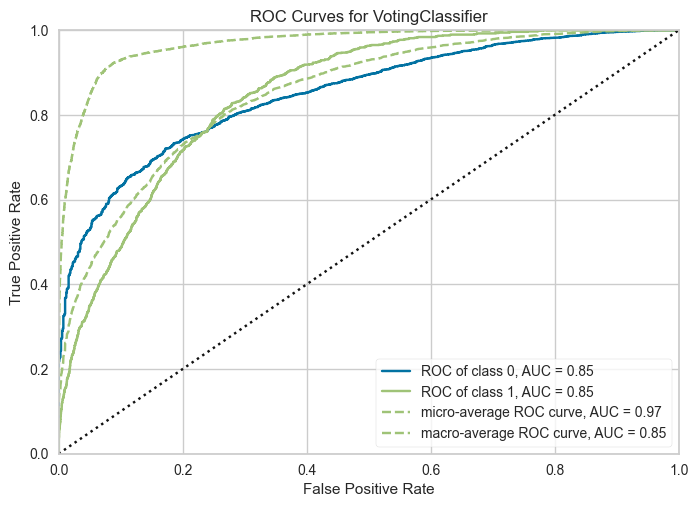

In [ ]:
plot_model(estimator = final_model, plot = 'auc')

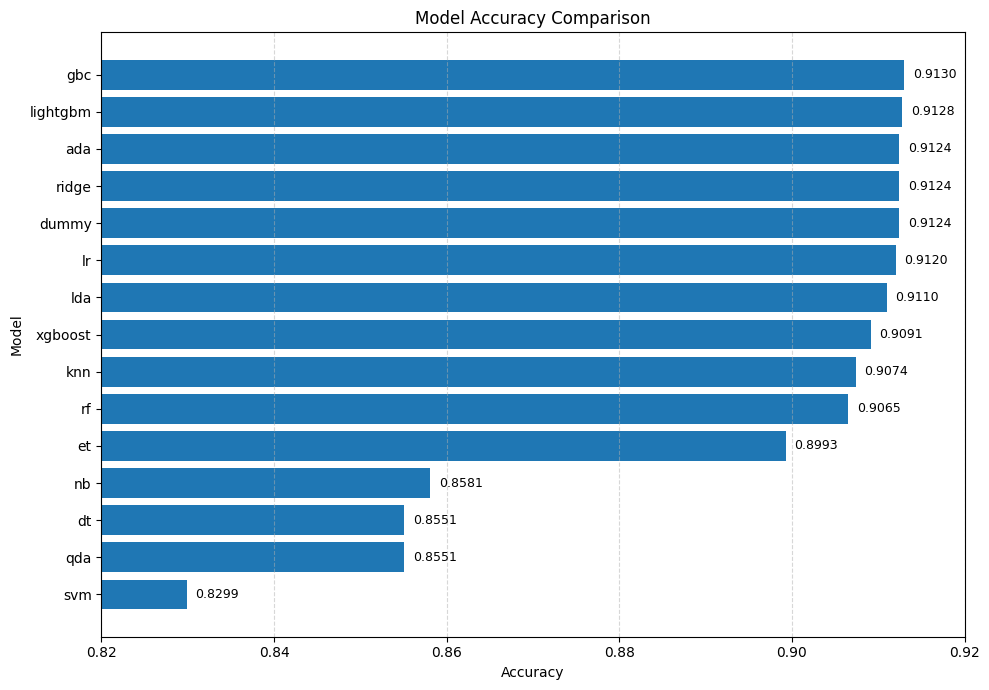

In [ ]:
import matplotlib.pyplot as plt

# 모델명
models = [
    "gbc", "lightgbm", "ada", "ridge", "dummy",
    "lr", "lda", "xgboost", "knn", "rf",
    "et", "nb", "dt", "qda", "svm"
]

# Accuracy 값 (필요하면 여기만 수정)
accuracy = [
    0.9130, 0.9128, 0.9124, 0.9124, 0.9124,
    0.9120, 0.9110, 0.9091, 0.9074, 0.9065,
    0.8993, 0.8581, 0.8551, 0.8551, 0.8299
]

plt.figure(figsize=(10, 7))

bars = plt.barh(models, accuracy)

# 값 표시
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.001,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.4f}",
        va="center",
        fontsize=9
    )

plt.xlabel("Accuracy")
plt.ylabel("Model")
plt.title("Model Accuracy Comparison")

# 범위를 좁혀 차이가 잘 보이도록 설정
plt.xlim(0.82, 0.92)

plt.grid(axis="x", linestyle="--", alpha=0.5)

# Accuracy가 높은 모델이 위에 오도록
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

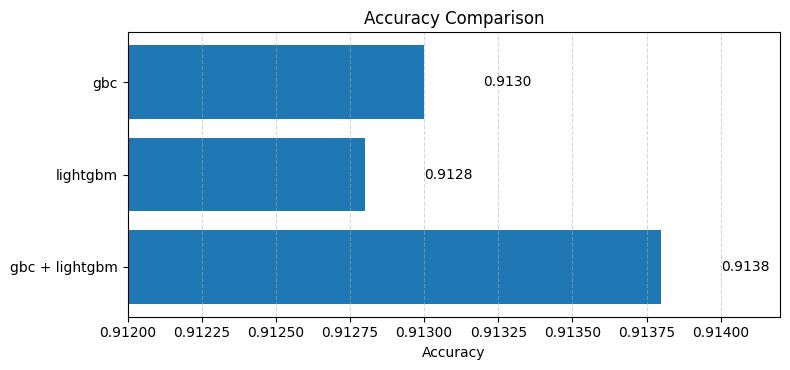

In [ ]:
import matplotlib.pyplot as plt

# 모델명
models = [
    "gbc",
    "lightgbm",
    "gbc + lightgbm"
]

# Accuracy 값
accuracy = [
    0.9130,
    0.9128,
    0.9138
]

# 색상 (gbc, lightgbm: 파란색 / Voting: 하늘색)


plt.figure(figsize=(8, 3.8))

bars = plt.barh(models, accuracy)

# 값 표시
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.0002,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.4f}",
        va="center",
        fontsize=10
    )

plt.xlabel("Accuracy")
plt.title("Accuracy Comparison")

# 차이가 잘 보이도록 범위 조정
plt.xlim(0.9120, 0.9142)

plt.grid(axis="x", linestyle="--", alpha=0.5)

# 위에서부터 gbc → lightgbm → gbc+lightgbm 순으로 표시
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()